In [1]:
#importing dependencies
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
# Prunable Linear Layer
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))
        # Gate scores (learnable)
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))
    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)   # values in (0,1)
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)
    def get_gates(self):
        return torch.sigmoid(self.gate_scores)

In [3]:
#  Neural Network
class PrunableNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = PrunableLinear(32 * 32 * 3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def get_all_gates(self):
        return [
            self.fc1.get_gates(),
            self.fc2.get_gates(),
            self.fc3.get_gates()
        ]

In [4]:
#  Sparsity Loss (L1)
def sparsity_loss(model):
    loss = 0
    for gates in model.get_all_gates():
        loss += gates.sum()
    return loss

In [5]:
#  Data Loaders
def get_data():
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
    return train_loader, test_loader

In [6]:
# Training Loop
def train(model, train_loader, optimizer, lambda_val, epochs=10):
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for data, target in train_loader:
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()

            output = model(data)
            ce_loss = F.cross_entropy(output, target)
            sp_loss = sparsity_loss(model)

            loss = ce_loss + lambda_val * sp_loss

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

In [7]:
#  Evaluation
def evaluate(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)

            preds = output.argmax(dim=1)
            correct += (preds == target).sum().item()
            total += target.size(0)

    accuracy = correct / total
    return accuracy


In [8]:
# Sparsity Calculation
def calculate_sparsity(model, threshold=1e-2):
    total = 0
    zero = 0

    for gates in model.get_all_gates():
        total += gates.numel()
        zero += (gates < threshold).sum().item()

    return 100 * zero / total


In [13]:
def plot_gates(model):
    with torch.no_grad():  # extra safety
        all_gates = torch.cat([
            g.flatten().cpu()
            for g in model.get_all_gates()
        ])

    plt.hist(all_gates.numpy(), bins=50)
    plt.title("Gate Distribution (Post Training)")
    plt.xlabel("Gate Value")
    plt.ylabel("Frequency")
    plt.grid()
    plt.show()


In [14]:
#  Main Experiment
def run_experiment(lambda_val):
    print(f"\nRunning for lambda = {lambda_val}")

    train_loader, test_loader = get_data()
    model = PrunableNN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    train(model, train_loader, optimizer, lambda_val)

    acc = evaluate(model, test_loader)
    sparsity = calculate_sparsity(model)

    print(f"Lambda: {lambda_val} | Accuracy: {acc:.4f} | Sparsity: {sparsity:.2f}%")

    return model, acc, sparsity



Running for lambda = 1e-05
Epoch 1, Loss: 3754.2458
Epoch 2, Loss: 3199.8853
Epoch 3, Loss: 2770.0155
Epoch 4, Loss: 2423.4278
Epoch 5, Loss: 2147.2128
Epoch 6, Loss: 1929.1381
Epoch 7, Loss: 1755.7127
Epoch 8, Loss: 1613.3700
Epoch 9, Loss: 1497.9862
Epoch 10, Loss: 1400.4675
Lambda: 1e-05 | Accuracy: 0.5498 | Sparsity: 0.44%

Running for lambda = 0.0001
Epoch 1, Loss: 31363.3790
Epoch 2, Loss: 26076.5997
Epoch 3, Loss: 21274.8473
Epoch 4, Loss: 17125.2660
Epoch 5, Loss: 13719.3989
Epoch 6, Loss: 11033.8655
Epoch 7, Loss: 8963.8852
Epoch 8, Loss: 7379.9869
Epoch 9, Loss: 6165.2464
Epoch 10, Loss: 5222.3539
Lambda: 0.0001 | Accuracy: 0.5601 | Sparsity: 1.44%

Running for lambda = 0.001
Epoch 1, Loss: 307562.3340
Epoch 2, Loss: 255216.2510
Epoch 3, Loss: 206987.2771
Epoch 4, Loss: 164935.7126
Epoch 5, Loss: 130133.6051
Epoch 6, Loss: 102499.4085
Epoch 7, Loss: 81105.1715
Epoch 8, Loss: 64697.6552
Epoch 9, Loss: 52090.8719
Epoch 10, Loss: 42322.4476
Lambda: 0.001 | Accuracy: 0.5455 | Sp

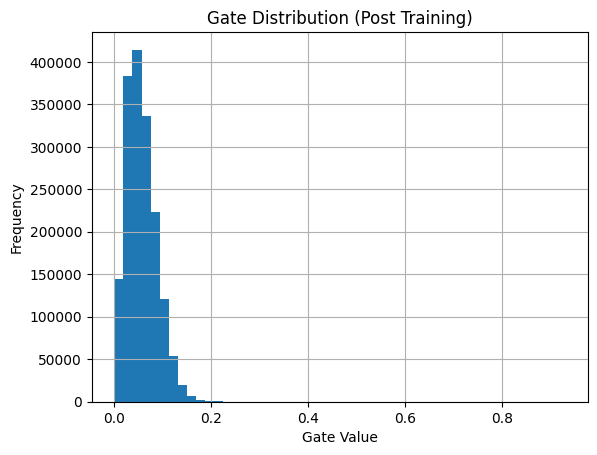

In [15]:
#  Run Multiple Lambdas
if __name__ == "__main__":
    lambdas = [1e-5, 1e-4, 1e-3]

    results = []

    for l in lambdas:
        model, acc, sparsity = run_experiment(l)
        results.append((l, acc, sparsity))

    print("\nFinal Results:")
    for r in results:
        print(f"Lambda: {r[0]}, Accuracy: {r[1]:.4f}, Sparsity: {r[2]:.2f}%")

    # Plot best model
    best_model = model
    plot_gates(best_model)